# Libs

In [ ]:
import gdown
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from scipy.stats.mstats import winsorize
from statsmodels.stats.diagnostic import linear_reset
import statsmodels.api as sm
import seaborn as sns
from sklearn.model_selection import KFold


sns.set_theme(style="darkgrid", palette="muted")

In [ ]:
# datos pib y luz


url = 'drive url'
output = 'q_data.csv'
gdown.download(url, output, quiet=False)

In [ ]:
quarterly_df = pd.read_csv(output)
print(quarterly_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   municipio               48 non-null     object 
 1   quarter                 48 non-null     object 
 2   fecha                   48 non-null     object 
 3   total_pixeles_median    48 non-null     float64
 4   suma_rad_trend_sum      48 non-null     float64
 5   suma_rad_trend_mean     48 non-null     float64
 6   suma_rad_trend_std      48 non-null     float64
 7   suma_rad_trend_median   48 non-null     float64
 8   media_rad_trend_mean    48 non-null     float64
 9   std_rad_trend_mean      48 non-null     float64
 10  max_rad_trend_max       48 non-null     float64
 11  min_rad_trend_min       48 non-null     float64
 12  p25_rad_trend_mean      48 non-null     float64
 13  mediana_rad_trend_mean  48 non-null     float64
 14  p75_rad_trend_mean      48 non-null     floa

In [ ]:
quarterly_df.columns

Index(['municipio', 'quarter', 'fecha', 'total_pixeles_median',
       'suma_rad_trend_sum', 'suma_rad_trend_mean', 'suma_rad_trend_std',
       'suma_rad_trend_median', 'media_rad_trend_mean', 'std_rad_trend_mean',
       'max_rad_trend_max', 'min_rad_trend_min', 'p25_rad_trend_mean',
       'mediana_rad_trend_mean', 'p75_rad_trend_mean', 'entidad_federativa',
       'porc_pob', 'pibe', 'pib_mun'],
      dtype='object')

In [ ]:
def preprocess(dataframe, log = True,  encode = True, n_lags= 2):
  df = dataframe.copy()

  df['quarter'] = pd.PeriodIndex(df['quarter'], freq='Q')
  df['year'] = df['fecha'].dt.year

  log_cols =  ['pib_mun', 'suma_rad_trend_sum', 'suma_rad_trend_mean', 'suma_rad_trend_std',
       'suma_rad_trend_median', 'media_rad_trend_mean', 'std_rad_trend_mean',
       'max_rad_trend_max', 'min_rad_trend_min', 'p25_rad_trend_mean',
       'mediana_rad_trend_mean', 'p75_rad_trend_mean']

  if log:
    df[log_cols] = df[log_cols].replace(0, 1e-5)
    df[log_cols]= df[log_cols].apply(np.log)

  df = df.sort_values(['municipio', 'quarter'])

  col = 'suma_rad_trend_median'

  for lag in range(1, n_lags + 1):
    df[f'{col}_lag{lag}'] = df.groupby('municipio')[col].shift(lag)

  if encode:
    df = pd.get_dummies(
        df,
        columns= ['municipio'],
        drop_first=False,
        dtype=int
    )

    df = df.dropna()

  return df

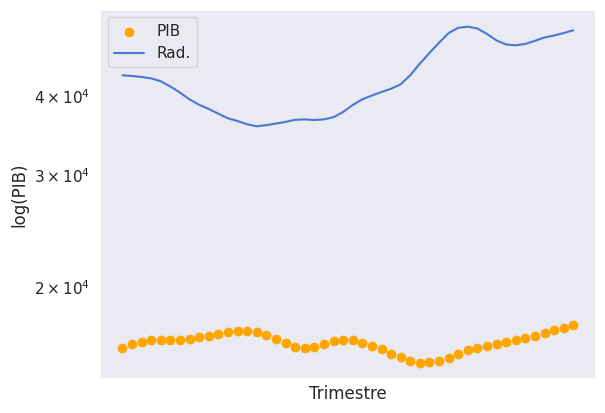

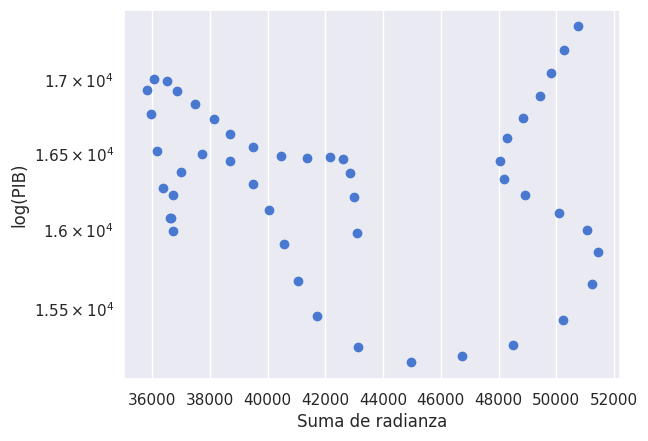

In [ ]:
plt.scatter(quarterly_df.fecha,quarterly_df.pib_mun,color='orange',label='PIB')
plt.plot(quarterly_df.fecha,quarterly_df.suma_rad_trend_mean,label='Rad.')
plt.yscale('log')
plt.xticks(ticks=[])
plt.ylabel('log(PIB)')
plt.xlabel('Trimestre')
plt.legend()
plt.show()

plt.scatter(quarterly_df.suma_rad_trend_mean,quarterly_df.pib_mun)
plt.xlabel('Suma de radianza')
plt.ylabel('log(PIB)')
plt.yscale('log')
plt.show()

In [ ]:
quarterly_df['fecha'] = pd.to_datetime(quarterly_df['fecha'])
quarterly_df_coded = preprocess(quarterly_df,log = True, encode = False)
quarterly_df_coded.columns

# Pruebas linealidad

1. No time

In [ ]:
# no geo effects no time
features = ['total_pixeles_median',
       'suma_rad_trend_sum', 'suma_rad_trend_mean', 'suma_rad_trend_std',
       'suma_rad_trend_median', 'media_rad_trend_mean', 'std_rad_trend_mean',
       'max_rad_trend_max', 'min_rad_trend_min', 'p25_rad_trend_mean',
       'mediana_rad_trend_mean', 'p75_rad_trend_mean']
target = 'pib_mun'


X = quarterly_df_coded[features]
y = quarterly_df_coded[target]

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=features,
    index=X.index
)

X_scaled = sm.add_constant(X_scaled)


In [ ]:
# regresion no time
model_reg = sm.OLS(y, X_scaled).fit()
print(model_reg.summary())

                            OLS Regression Results                            
Dep. Variable:                pib_mun   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     6.794
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           6.69e-06
Time:                        00:14:44   Log-Likelihood:                 120.53
No. Observations:                  48   AIC:                            -219.1
Df Residuals:                      37   BIC:                            -198.5
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      9

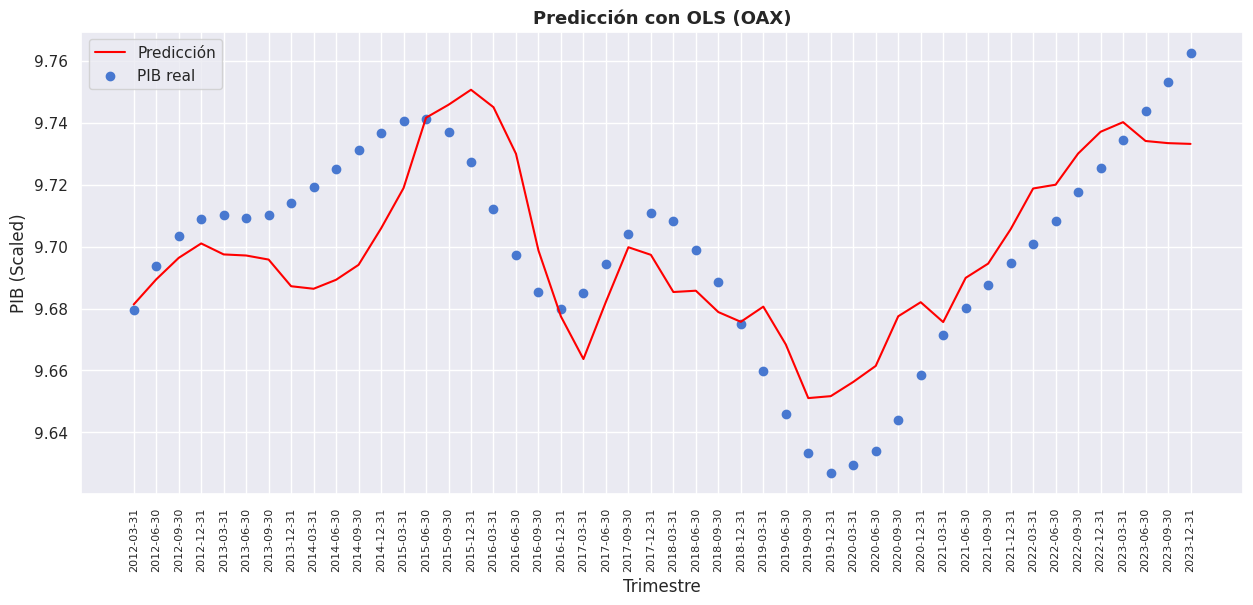

In [ ]:
y_pred = model_reg.predict(X_scaled)

plt.figure(figsize=(15,6))
plt.plot(X_scaled.index,y_pred,color='red',label='Predicción')
plt.scatter(X_scaled.index,y,label='PIB real')
plt.xticks(ticks=X_scaled.index,labels=quarterly_df_coded['fecha'].dt.strftime('%Y-%m-%d'),rotation=90,fontsize=8)
plt.title('Predicción con OLS (OAX)',fontsize=13, fontweight="bold")
plt.ylabel('PIB (Scaled)')
plt.xlabel('Trimestre')
plt.legend()
plt.show()

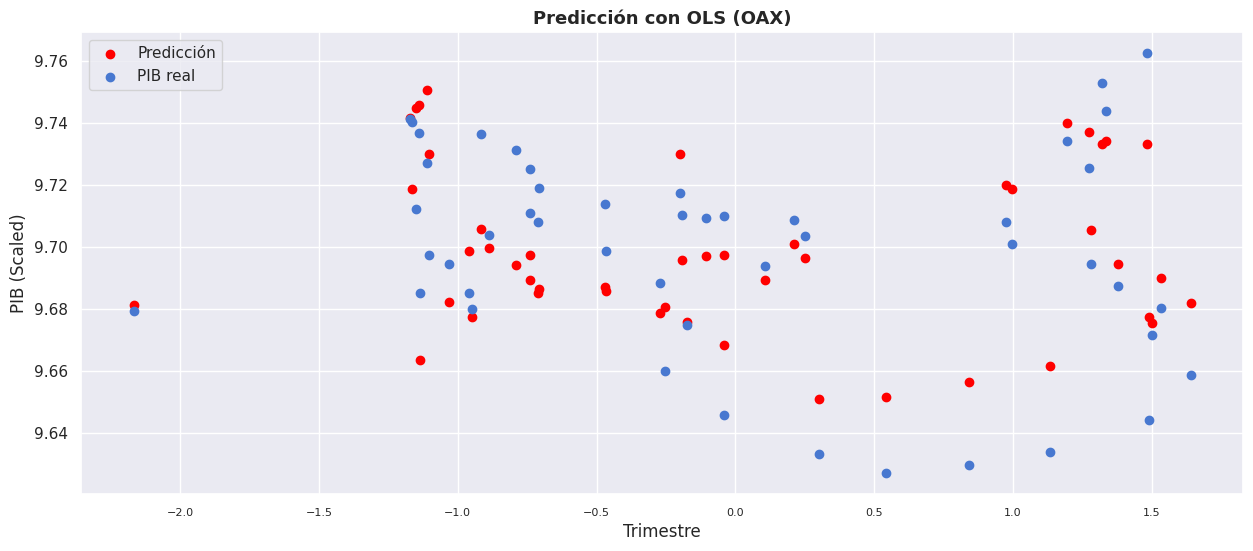

In [ ]:
plt.figure(figsize=(15,6))
plt.scatter(X_scaled.suma_rad_trend_sum,y_pred,color='red',label='Predicción')
plt.scatter(X_scaled.suma_rad_trend_sum,y,label='PIB real')
plt.xticks(fontsize=8)
plt.title('Predicción con OLS (OAX)',fontsize=13, fontweight="bold")
plt.ylabel('PIB (Scaled)')
plt.xlabel('Trimestre')
plt.legend()
plt.show()


Test de Shapiro-Wilk:
Estadístico: 0.9680
p-value: 0.211911
H0: Los residuos son normales
Si p < 0.05 → Rechazamos normalidad


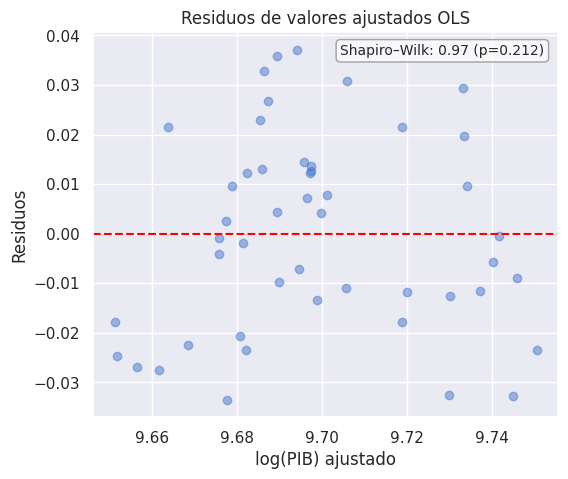

In [ ]:
from scipy.stats import shapiro

residuals = model_reg.resid

stat, p_value = shapiro(residuals)
print(f"\nTest de Shapiro-Wilk:")
print(f"Estadístico: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"H0: Los residuos son normales")
print(f"Si p < 0.05 → Rechazamos normalidad")


plt.figure(figsize=(6,5))
plt.scatter(model_reg.fittedvalues, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("log(PIB) ajustado")
plt.ylabel("Residuos")
plt.title("Residuos de valores ajustados OLS")


plt.annotate(
    f"Shapiro–Wilk: {stat:.2f} (p={p_value:.3f})",
    xy=(0.97, 0.97), xycoords='axes fraction',
    ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
)

plt.show()

Text(0.5, 0, 'Residuos(OLS)')

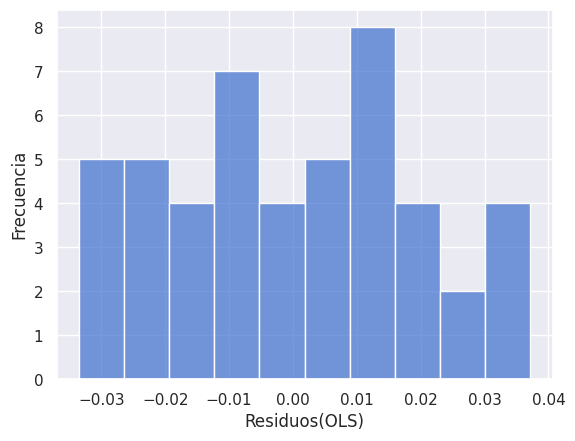

In [ ]:
sns.histplot(x=residuals,bins=10)
plt.ylabel('Frecuencia')
plt.xlabel('Residuos(OLS)')

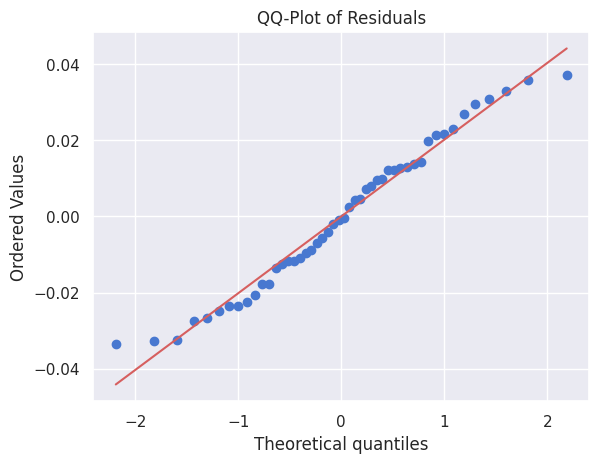

In [ ]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals")
plt.show()

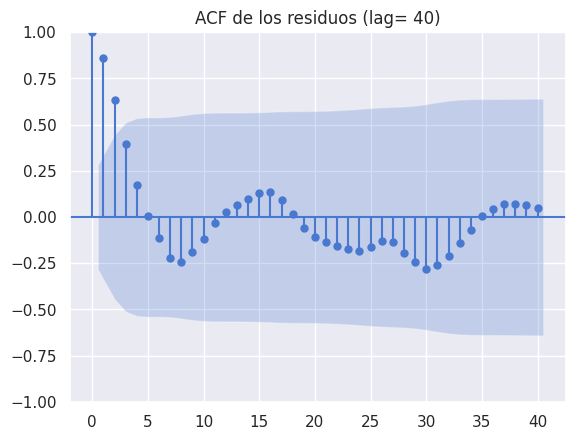

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
lag = 40
plot_acf(residuals, lags=lag)
plt.title(f"ACF de los residuos (lag= {lag})")
plt.show()

Con time

In [ ]:
# reg time
features = ['total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean']
target = 'pib_mun'

X = quarterly_df_coded[features]

year_dummies = pd.get_dummies(quarterly_df_coded['year'], prefix='year', drop_first=True)


X = pd.concat([X, year_dummies], axis=1)

y = quarterly_df_coded[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = sm.add_constant(X_scaled)

model_time = sm.OLS(y, X_scaled).fit()
print(model_time.summary())

                            OLS Regression Results                            
Dep. Variable:                pib_mun   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     36.23
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           3.17e-14
Time:                        00:18:32   Log-Likelihood:                 177.35
No. Observations:                  48   AIC:                            -310.7
Df Residuals:                      26   BIC:                            -269.5
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.6987      0.001   8224.144      0.0


Test de Shapiro-Wilk:
Estadístico: 0.9491
p-value: 0.036683
H0: Los residuos son normales
Si p < 0.05 → Rechazamos normalidad


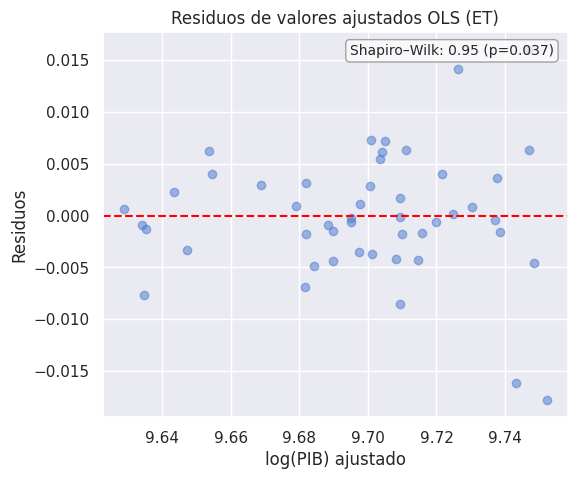

In [ ]:
residuals = model_time.resid

stat, p_value = shapiro(residuals)
print(f"\nTest de Shapiro-Wilk:")
print(f"Estadístico: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"H0: Los residuos son normales")
print(f"Si p < 0.05 → Rechazamos normalidad")


plt.figure(figsize=(6,5))
plt.scatter(model_time.fittedvalues, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("log(PIB) ajustado")
plt.ylabel("Residuos")
plt.title("Residuos de valores ajustados OLS (ET)")


plt.annotate(
    f"Shapiro–Wilk: {stat:.2f} (p={p_value:.3f})",
    xy=(0.97, 0.97), xycoords='axes fraction',
    ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
)

plt.show()

In [ ]:
corr = np.corrcoef(y, y_pred)[0,1]
real_pct_change = y.values[1:] / y.values[:-1] - 1
pred_pct_change = y_pred[1:] / y_pred[:-1] - 1
corr_pct = np.corrcoef(real_pct_change, pred_pct_change)[0,1]

print("Corr.de Pearson: ",corr)
print("Corr.de de P variación porcentual: ",corr_pct)

Corr.de Pearson:  0.9833388186089721
Corr.de de P variación porcentual:  0.7058942904530005


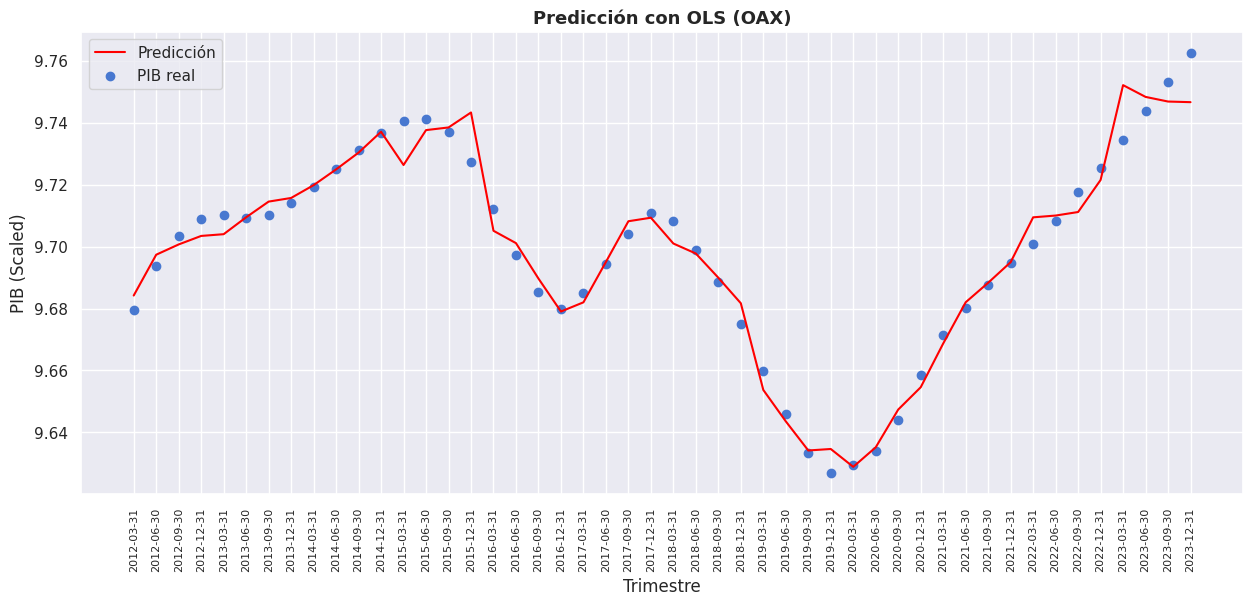

In [ ]:
y_pred = model_time.predict(X_scaled)

plt.figure(figsize=(15,6))
plt.plot(y.index,y_pred,color='red',label='Predicción')
plt.scatter(y.index,y,label='PIB real')
plt.xticks(ticks=y.index,labels=quarterly_df_coded['fecha'].dt.strftime('%Y-%m-%d'),rotation=90,fontsize=8)
plt.title('Predicción con OLS (OAX)',fontsize=13, fontweight="bold")
plt.ylabel('PIB (Scaled)')
plt.xlabel('Trimestre')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import explained_variance_score

evs = explained_variance_score(y, y_pred)
print(evs)

-1.3303865538858886


# Random forest no lags

In [ ]:
features = ['total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean', 'year']


X = quarterly_df_coded[features]
y = quarterly_df_coded['pib_mun']


In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

# Definir TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
# Grid Search 
## Definir grid de hiperparámetros
param_grid = {
   'n_estimators': [50, 100, 200],
   'max_depth': [5, 10, 15, 20, None],
   'min_samples_split': [2, 5, 10],
   'min_samples_leaf': [1, 2, 4],
   'max_features': ['sqrt', 'log2', None],
   'bootstrap': [True, False]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

scorer = make_scorer(mean_squared_error, greater_is_better=False)

# GridSearchCV con TimeSeriesSplit
grid_search = GridSearchCV(
   estimator=rf,
   param_grid=param_grid,
   cv=tscv,  # Usar TimeSeriesSplit
   scoring=scorer,
   n_jobs=-1,
   verbose=2,
   return_train_score=True
)

# Asegurarse de que los datos están ordenados por fecha
quarterly_df_coded_sorted = quarterly_df_coded.sort_values('fecha').reset_index(drop=True)
X = quarterly_df_coded_sorted[features]
y = quarterly_df_coded_sorted['pib_mun']

# Ajustar
print("Iniciando búsqueda de hiperparámetros...")
grid_search.fit(X, y)

# Resultados
print("\n" + "="*70)
print("RESULTADOS DEL GRID SEARCH")
print("="*70)
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor score (neg MSE): {grid_search.best_score_:.4f}")
print(f"Mejor RMSE: {np.sqrt(-grid_search.best_score_):.4f}")

# Ver todos los resultados
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')
print("\nTop 5 combinaciones:")
print(results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head())

# Modelo óptimo
best_model = grid_search.best_estimator_

In [ ]:

kf = KFold(n_splits=5, shuffle=True) # si no hay shuffle no ocupa random state

fold_metricas = []
fold_global_metrics = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


    rf = RandomForestRegressor(
      max_depth=10,
      max_features='sqrt',
      min_samples_leaf=1,
      min_samples_split=2,
      n_estimators=200,
      random_state=42
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    y_test_real = np.exp(y_test)
    y_pred_real = np.exp(y_pred)

    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, y_pred_real)


    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100


    fold_global_metrics.append({
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

    # Combine test with predictions
    df_fold = X_test.copy()
    df_fold['y_real'] = y_test
    df_fold['y_pred'] = y_pred



# Métricas globales promedio entre folds
df_global_metrics = pd.DataFrame(fold_global_metrics).mean().to_dict()
print("📊 Global metrics (average across folds):")
print(df_global_metrics)



📊 Global metrics (average across folds):
{'MSE': 53529.267909637456, 'RMSE': 222.15558867565727, 'MAE': 180.3917869352045, 'MAPE': 1.1139139650922854}


# Timesplit 

In [ ]:
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

fold_global_metrics = []

# se necesita ordenar primero
df_processed_sorted = quarterly_df_coded.sort_values('fecha').reset_index(drop=True)

X = df_processed_sorted[features]
y = df_processed_sorted['pib_mun']

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    print(f"\n🔄 Processing Fold {fold}/{n_splits}...")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf = RandomForestRegressor(
      max_depth=10,
      max_features='sqrt',
      min_samples_leaf=1,
      min_samples_split=2,
      n_estimators=200,
      random_state=42
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    y_test_values = y_test.values
    y_pred_values = np.array(y_pred)

    y_test_real = np.exp(y_test)
    y_pred_real = np.exp(y_pred)

    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, y_pred_real)


    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

    fold_global_metrics.append({
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

    # Combine test with predictions
    df_fold = X_test.copy()
    df_fold['y_real'] = y_test
    df_fold['y_pred'] = y_pred

# Métricas globales promedio entre folds
df_global_metrics = pd.DataFrame(fold_global_metrics).mean().to_dict()
print("📊 Global metrics (average across folds):")
print(df_global_metrics)




🔄 Processing Fold 1/5...

🔄 Processing Fold 2/5...

🔄 Processing Fold 3/5...

🔄 Processing Fold 4/5...

🔄 Processing Fold 5/5...
📊 Global metrics (average across folds):
{'MSE': 373382.64447943214, 'RMSE': 574.638341428769, 'MAE': 522.497942629486, 'MAPE': 3.2114079957174106}


# Forecast

In [ ]:
n_preds = 4

# Tomar los últimos n trimestres de cada municipio

X_train = df_processed_sorted[features].iloc[:-n_preds].astype(float)
X_test = df_processed_sorted[features].iloc[-n_preds:].astype(float)
y_train = df_processed_sorted['pib_mun'].iloc[:-n_preds].astype(float)
y_test = df_processed_sorted['pib_mun'].iloc[-n_preds:].astype(float)

rf = RandomForestRegressor(
      max_depth=10,
      max_features='sqrt',
      min_samples_leaf=1,
      min_samples_split=2,
      n_estimators=200,
      random_state=42
    )

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)



y_test_values = y_test.values
y_pred_values = np.array(y_pred)

y_test_real = np.exp(y_test) # se TIENE que regresar a la escala original no puede ser en log
y_pred_real = np.exp(y_pred)


# Métricas

mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_real, y_pred_real)

mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100


fold_global_metrics.append({
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

# Métricas globales promedio entre folds
df_global_metrics = pd.DataFrame(fold_global_metrics).mean().to_dict()
print("📊 Global metrics (average across folds):")
print(df_global_metrics)

# Preparar datos para visualización
df_train = df_processed_sorted.loc[X_train.index].copy()
df_train['y_real'] = y_train

df_test = df_processed_sorted.loc[X_test.index].copy()
df_test['y_real'] = y_test
df_test['y_pred'] = y_pred


📊 Global metrics (average across folds):
{'MSE': 321867.59875839506, 'RMSE': 464.3419862078521, 'MAE': 426.7691251804944, 'MAPE': 3.7562106343035704, 'Corr': -0.9986164732796285, 'Corr PCT': 0.7109007778559931}


# RF Lags

In [ ]:
features = ['total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean', 'year','suma_rad_trend_median_lag1',
       'suma_rad_trend_median_lag2']


X = quarterly_df_coded[features]
y = quarterly_df_coded['pib_mun']

**Kfold**

In [ ]:

kf = KFold(n_splits=5, shuffle=True)
fold_metricas = []
fold_global_metrics = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


    rf = RandomForestRegressor(
      max_depth=10,
      max_features='sqrt',
      min_samples_leaf=1,
      min_samples_split=2,
      n_estimators=200,
      random_state=42
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    y_test_real = np.exp(y_test)
    y_pred_real = np.exp(y_pred)

    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, y_pred_real)


    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

    fold_global_metrics.append({
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape\
    })

    # Combine test with predictions
    df_fold = X_test.copy()
    df_fold['y_real'] = y_test
    df_fold['y_pred'] = y_pred



# Métricas globales promedio entre folds
df_global_metrics = pd.DataFrame(fold_global_metrics).mean().to_dict()
print("📊 Global metrics (average across folds):")
print(df_global_metrics)



📊 Global metrics (average across folds):
{'MSE': 57215.19505680519, 'RMSE': 232.15053311614116, 'MAE': 187.88628232346667, 'MAPE': 1.157895909362296}


**Timesplit**

In [ ]:
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

fold_global_metrics = []

# se necesita ordenar primero
df_processed_sorted = quarterly_df_coded.sort_values('fecha').reset_index(drop=True)

X = df_processed_sorted[features]
y = df_processed_sorted['pib_mun']

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    print(f"\n🔄 Processing Fold {fold}/{n_splits}...")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf = RandomForestRegressor(
      bootstrap=False,
      max_depth=10,
      max_features='sqrt',
      min_samples_leaf=1,
      min_samples_split=2,
      n_estimators=200,
      random_state=42
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    y_test_values = y_test.values
    y_pred_values = np.array(y_pred)


    y_test_real = np.exp(y_test)
    y_pred_real = np.exp(y_pred)

    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, y_pred_real)

    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

    fold_global_metrics.append({
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

    # Combine test with predictions
    df_fold = X_test.copy()
    df_fold['y_real'] = y_test
    df_fold['y_pred'] = y_pred

# Métricas globales promedio entre folds
df_global_metrics = pd.DataFrame(fold_global_metrics).mean().to_dict()
print("📊 Global metrics (average across folds):")
print(df_global_metrics)




🔄 Processing Fold 1/5...

🔄 Processing Fold 2/5...

🔄 Processing Fold 3/5...

🔄 Processing Fold 4/5...

🔄 Processing Fold 5/5...
📊 Global metrics (average across folds):
{'MSE': 390942.27798117243, 'RMSE': 589.6880564006387, 'MAE': 530.6605961818584, 'MAPE': 3.2603744754614765}


**Forecast**

In [ ]:
n_preds = 4

# Tomar los últimos n trimestres de cada municipio

# se necesita ordenar primero
df_processed_sorted = quarterly_df_coded.sort_values('fecha').reset_index(drop=True)

X_train = df_processed_sorted[features].iloc[:-n_preds].astype(float)
X_test = df_processed_sorted[features].iloc[-n_preds:].astype(float)
y_train = df_processed_sorted['pib_mun'].iloc[:-n_preds].astype(float)
y_test = df_processed_sorted['pib_mun'].iloc[-n_preds:].astype(float)

rf = RandomForestRegressor(
      bootstrap=False,
      max_depth=10,
      max_features='sqrt',
      min_samples_leaf=1,
      min_samples_split=2,
      n_estimators=200,
      random_state=42
    )

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

y_test_values = y_test.values
y_pred_values = np.array(y_pred)

y_test_real = np.exp(y_test)
y_pred_real = np.exp(y_pred)


# Métricas

mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_real, y_pred_real)

mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100


fold_global_metrics.append({
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

# Métricas globales promedio entre folds
df_global_metrics = pd.DataFrame(fold_global_metrics).mean().to_dict()
print("📊 Global metrics (average across folds):")
print(df_global_metrics)

# Preparar datos para visualización
df_train = df_processed_sorted.loc[X_train.index].copy()
df_train['y_real'] = y_train

df_test = df_processed_sorted.loc[X_test.index].copy()
df_test['y_real'] = y_test
df_test['y_pred'] = y_pred


📊 Global metrics (average across folds):
{'MSE': 442600.56440128473, 'RMSE': 630.9388681157392, 'MAE': 575.1146241932028, 'MAPE': 3.4902895242325354}


# OLS + RF

**Kfold**

In [ ]:
from math import sqrt
import statsmodels.api as sm

#features = ['total_pixeles_median', 'suma_rad_trend_sum',
#       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
#       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
#       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
#       'p75_rad_trend_mean', 'year', 'suma_rad_trend_median_lag1',
#       'suma_rad_trend_median_lag2']

features = ['total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean', 'year']

df_ols = quarterly_df_coded.dropna()

In [ ]:
quarterly_df_coded.isna().sum()

,0
municipio,0
quarter,0
fecha,0
total_pixeles_median,0
suma_rad_trend_sum,0
suma_rad_trend_mean,0
suma_rad_trend_std,0
suma_rad_trend_median,0
media_rad_trend_mean,0
std_rad_trend_mean,0


In [ ]:
from sklearn.model_selection import train_test_split

fold_global_metrics = []


X = df_ols[features]
y = df_ols['pib_mun']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)



scaler_X = StandardScaler()
scaler_y = StandardScaler()


X_train_scaled = scaler_X.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)


X_test_scaled = scaler_X.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

X_train_ols = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train_scaled, X_train_ols).fit()
y_hat_train_ols = ols_model.predict(X_train_ols)
residuals_train = y_train_scaled - y_hat_train_ols


rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    random_state=42
)

rf.fit(X_train_scaled, residuals_train)

X_test_ols = sm.add_constant(X_test_scaled, has_constant='add')


y_pred_test_ols_scaled = ols_model.predict(X_test_ols)

y_pred_test_rf_scaled = rf.predict(X_test_scaled)

y_pred_test_hybrid_scaled = y_pred_test_ols_scaled + y_pred_test_rf_scaled

y_pred_test_hybrid = scaler_y.inverse_transform(
    y_pred_test_hybrid_scaled.values.reshape(-1, 1)
).ravel()

y_test_real = np.exp(y_test)
y_pred_real = np.exp(y_pred_test_hybrid)

mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_real, y_pred_real)

# MAPE en escala original

mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100


fold_global_metrics.append({
    'MSE': mse,
    'RMSE': rmse,
    'MAE': mae,
    'MAPE': mape
})

# metricas train

y_pred_train_ols_scaled = y_hat_train_ols
y_pred_train_rf_scaled = rf.predict(X_train_scaled)
y_pred_train_hybrid_scaled = y_pred_train_ols_scaled + y_pred_train_rf_scaled
y_pred_train_hybrid = scaler_y.inverse_transform(
    y_pred_train_hybrid_scaled.values.reshape(-1, 1)
).ravel()

mse_train = mean_squared_error(y_train, y_pred_train_hybrid)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_pred_train_hybrid)

df_global_metrics = pd.DataFrame(fold_global_metrics)
print(df_global_metrics.to_string(index=False))



         MSE       RMSE        MAE     MAPE
56681.440017 238.078643 194.893572 1.176848


In [ ]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     98.52
Date:                Sat, 08 Nov 2025   Prob (F-statistic):           3.34e-17
Time:                        04:47:46   Log-Likelihood:                 17.894
No. Observations:                  36   AIC:                            -11.79
Df Residuals:                      24   BIC:                             7.213
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

**Timesplit**

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import statsmodels.api as sm

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

fold_global_metrics = []

# Asegurarse de que el df esté ordenado por fecha
df_processed_sorted = df_ols.sort_values('fecha').reset_index(drop=True)

X = df_processed_sorted[features]
y = df_processed_sorted['pib_mun']

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    print(f"\n Processing Fold {fold}/{n_splits}...")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Escalar X e y
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

    # Convertir X escalados de vuelta a DataFrame para mantener nombres de columnas
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

    # Paso 1: Entrenar OLS en datos escalados
    X_train_ols = sm.add_constant(X_train_scaled_df)
    ols_model = sm.OLS(y_train_scaled, X_train_ols).fit()
    y_hat_train_ols = ols_model.predict(X_train_ols)
    residuals_train = y_train_scaled - y_hat_train_ols

    # Paso 2: Entrenar RF en los residuales
    rf = RandomForestRegressor(
        n_estimators=50,
        max_leaf_nodes=None,
        max_depth=20,
        min_samples_leaf=1,
        random_state=42
    )
    rf.fit(X_train_scaled_df, residuals_train)

    # Paso 3: Predicción híbrida en test (escalado)
    X_test_ols = sm.add_constant(X_test_scaled_df, has_constant='add')
    y_hat_test_ols_scaled = ols_model.predict(X_test_ols)
    y_hat_test_rf_scaled = rf.predict(X_test_scaled_df)
    y_pred_hybrid_scaled = y_hat_test_ols_scaled + y_hat_test_rf_scaled

    # Desescalar las predicciones
    y_pred_hybrid = scaler_y.inverse_transform(y_pred_hybrid_scaled.values.reshape(-1, 1)).ravel()

    # Convertir todo a numpy arrays del mismo tamaño
    y_test_values = y_test.values
    y_pred_values = np.array(y_pred_hybrid)

     # Convertir de log a escala original para MAPE
    y_test_real = np.exp(y_test_values)
    y_pred_real = np.exp(y_pred_values)

    # Métricas globales del fold
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, y_pred_real)


    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100


    fold_global_metrics.append({
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

# Métricas globales promedio entre folds
df_global_metrics = pd.DataFrame(fold_global_metrics)
print("\n" + "="*60)
print(" MÉTRICAS GLOBALES (promedio entre folds):")
print("="*60)
print(df_global_metrics.mean())
print("\n Métricas por fold:")
print(df_global_metrics)


🔄 Processing Fold 1/5...

🔄 Processing Fold 2/5...

🔄 Processing Fold 3/5...

🔄 Processing Fold 4/5...

🔄 Processing Fold 5/5...

📊 MÉTRICAS GLOBALES (promedio entre folds):
MSE     518238.473327
RMSE       630.171221
MAE        565.032639
MAPE         3.441716
dtype: float64

📋 Métricas por fold:
            MSE         RMSE         MAE      MAPE
0  2.401350e+05   490.035752  441.887485  2.701632
1  1.653924e+05   406.684601  385.967689  2.362818
2  3.331776e+04   182.531534  168.001021  1.092960
3  9.573929e+05   978.464562  865.884855  5.379185
4  1.194954e+06  1093.139654  963.422146  5.671984


📊 Global metrics (average across folds):
{'MSE': 592681.1549681048, 'RMSE': 688.8577618740472, 'MAE': 628.9578815422014, 'MAPE': 3.788533208393243}


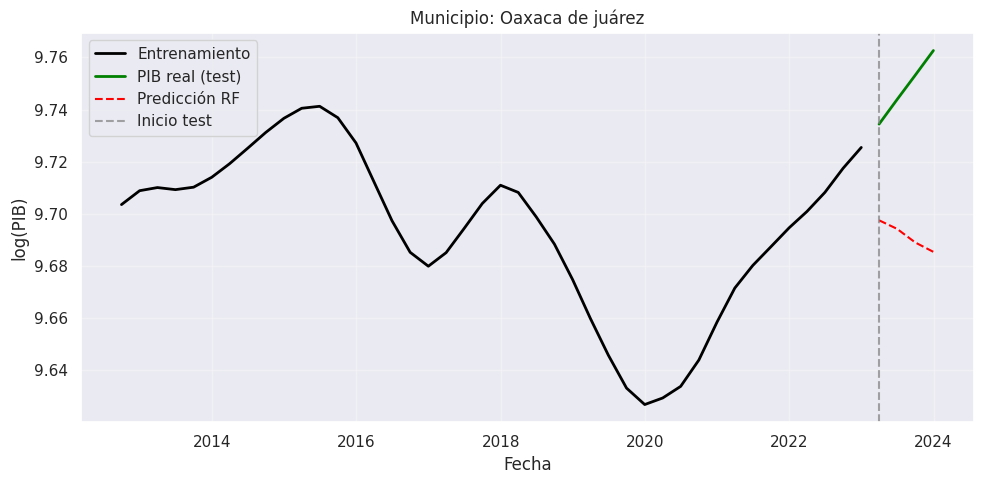

In [ ]:
n_preds = 4

df_processed_sorted = df_ols.sort_values('fecha').reset_index(drop=True)

X_train = df_processed_sorted[features].iloc[:-n_preds].astype(float)
X_test = df_processed_sorted[features].iloc[-n_preds:].astype(float)
y_train = df_processed_sorted['pib_mun'].iloc[:-n_preds].astype(float)
y_test = df_processed_sorted['pib_mun'].iloc[-n_preds:].astype(float)

# Escalar datos
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

#Paso 1: Entrenar OLS en datos escalados
X_train_ols = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train_scaled, X_train_ols).fit()
y_hat_train_ols = ols_model.predict(X_train_ols)
residuals_train = y_train_scaled - y_hat_train_ols

# Paso 2: Entrenar RF en los residuales
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train_scaled, residuals_train)

# Paso 3: Predicción híbrida en test (escalado)
X_test_ols = sm.add_constant(X_test_scaled, has_constant='add')
y_hat_test_ols_scaled = ols_model.predict(X_test_ols)
y_hat_test_rf_scaled = rf.predict(X_test_scaled)
y_pred_hybrid_scaled = y_hat_test_ols_scaled + y_hat_test_rf_scaled

# Desescalar las predicciones
y_pred_hybrid = scaler_y.inverse_transform(y_pred_hybrid_scaled.reshape(-1, 1)).ravel()

# Convertir todo a numpy arrays del mismo tamaño
y_test = y_test.values
y_pred = np.array(y_pred_hybrid)

y_test_real = np.exp(y_test) # se TIENE que regresar a la escala original no puede ser en log
y_pred_real = np.exp(y_pred)

# Métricas
mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_real, y_pred_real)

mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100


fold_global_metrics.append({
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

# Métricas globales promedio entre folds
df_global_metrics = pd.DataFrame(fold_global_metrics).mean().to_dict()
print("📊 Global metrics (average across folds):")
print(df_global_metrics)

# Preparar datos para visualización
df_train = df_processed_sorted.loc[X_train.index].copy()
df_train['y_real'] = y_train

df_test = df_processed_sorted.loc[X_test.index].copy()
df_test['y_real'] = y_test
df_test['y_pred'] = y_pred


plt.figure(figsize=(10, 5))
plt.plot(df_train['fecha'], df_train['y_real'],
                 label='Entrenamiento', color='black', linewidth=2)
plt.plot(df_test['fecha'], df_test['y_real'],
                 label='PIB real (test)', color='green', linewidth=2)
plt.plot(df_test['fecha'], df_test['y_pred'],
                 label='Predicción RF', color='red', linestyle='--')
plt.axvline(x=df_test['fecha'].iloc[0], color='gray',
                   linestyle='--', alpha=0.7, label='Inicio test')
m = "Oaxaca de Juárez"
plt.title(f'Municipio: {m.capitalize()}')
plt.xlabel('Fecha')
plt.ylabel('log(PIB)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualización

In [ ]:
def plot_model(df,metrics,model=None,quarter=True,figsize=(10,5)):

  mse = metrics[0]['MSE']
  rmse = metrics[0]['RMSE']
  mae = metrics[0]['MAE']
  mape = metrics[0]['MAPE']

  plt.figure(figsize=figsize)
  plt.title(f'Predicción con {model}',fontsize=13, fontweight="bold")
  plt.scatter(df['fecha'],df['y_real'],label='log(PIB) real')
  plt.plot(df['fecha'],df['y_pred'],label='log(PIB) pred',color='red')

  # bandas error
  plt.fill_between(df['fecha'],
                     df['y_pred'] - rmse,
                     df['y_pred'] + rmse,
                     alpha=0.2, color='red',
                     label=f'±RMSE', zorder=1)
  if quarter:
    plt.xticks(ticks=df['fecha'],labels=df['fecha'].dt.strftime('%Y-%m-%d'),rotation=90,fontsize=8)

  plt.ylabel('log(PIB)')
  plt.xlabel('Trimestre')
  plt.legend()
  plt.show()
  plt.show()


In [ ]:
# RF sin lags

features = ['total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean', 'year']


X = quarterly_df_coded[features]
y = quarterly_df_coded['pib_mun']

rf = RandomForestRegressor(
      max_depth=10,
      max_features='sqrt',
      min_samples_leaf=1,
      min_samples_split=2,
      n_estimators=200,
      random_state=42
    )

rf.fit(X, y)
y_pred = rf.predict(X)
rf_metrics = []
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

y_test_real = np.exp(y)
y_pred_real = np.exp(y_pred)
mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

rf_metrics.append({
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

df_rf_viz = X.copy()
df_rf_viz['fecha'] = quarterly_df_coded.fecha
df_rf_viz['y_real'] = y
df_rf_viz['y_pred'] = y_pred


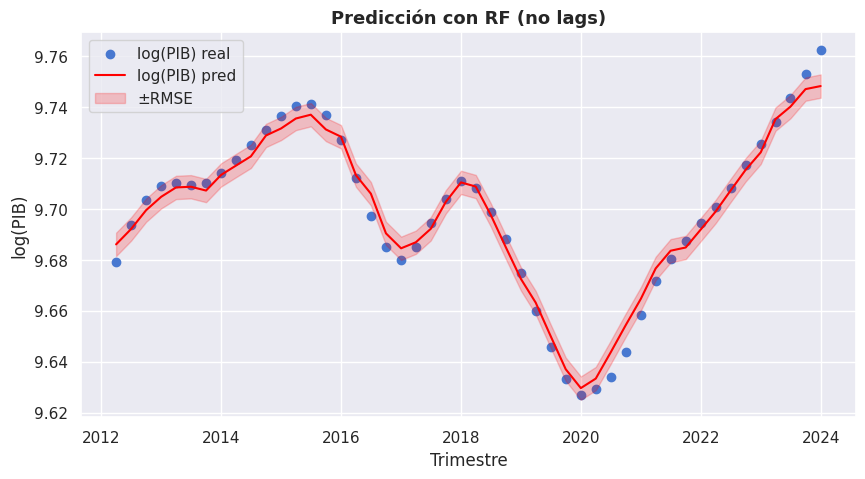

In [ ]:
plot_model(df_rf_viz,rf_metrics,model='RF (no lags)',quarter=False)

In [ ]:
# rf con lags


features = ['total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean', 'year','suma_rad_trend_median_lag1',
       'suma_rad_trend_median_lag2']


X_rf_lags = quarterly_df_coded[features]
y_rf_lags = quarterly_df_coded['pib_mun']

rf = RandomForestRegressor(
      max_depth=10,
      max_features='sqrt',
      min_samples_leaf=1,
      min_samples_split=2,
      n_estimators=200,
      random_state=42
    )

rf.fit(X_rf_lags, y_rf_lags)
y_pred = rf.predict(X_rf_lags)

rf_lags_metrics = []
mse = mean_squared_error(y_rf_lags, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_rf_lags, y_pred)

y_test_real = np.exp(y_rf_lags)
y_pred_real = np.exp(y_pred)
mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

rf_lags_metrics.append({
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

df_rf_lags_viz = X_rf_lags.copy()
df_rf_lags_viz['fecha'] = quarterly_df_coded.fecha
df_rf_lags_viz['y_real'] = y_rf_lags
df_rf_lags_viz['y_pred'] = y_pred


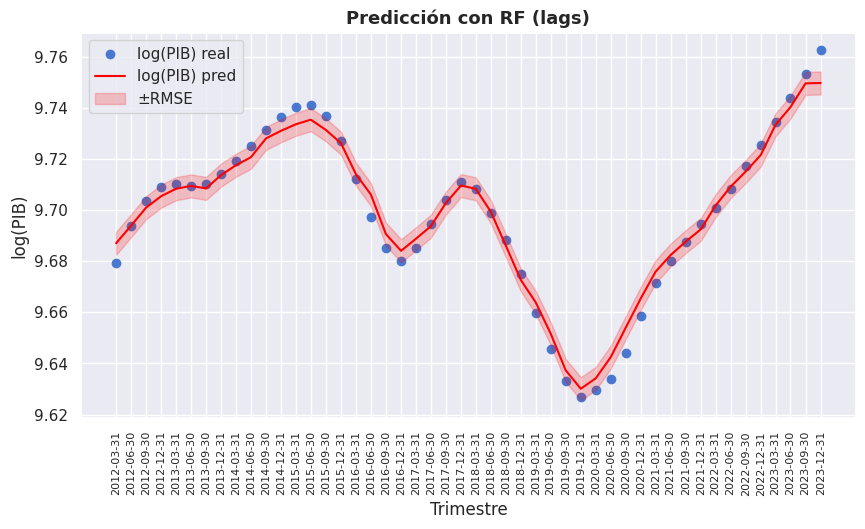

In [ ]:
plot_model(df_rf_lags_viz,rf_lags_metrics,model='RF (lags)',quarter=True)

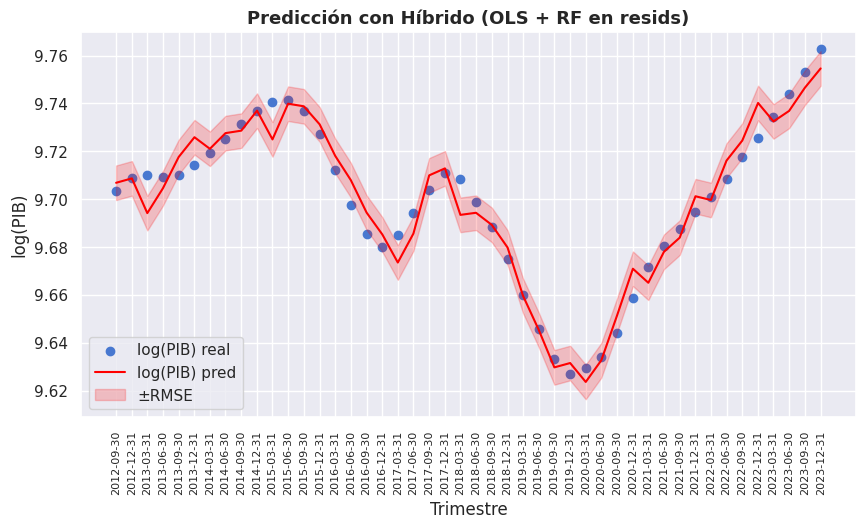

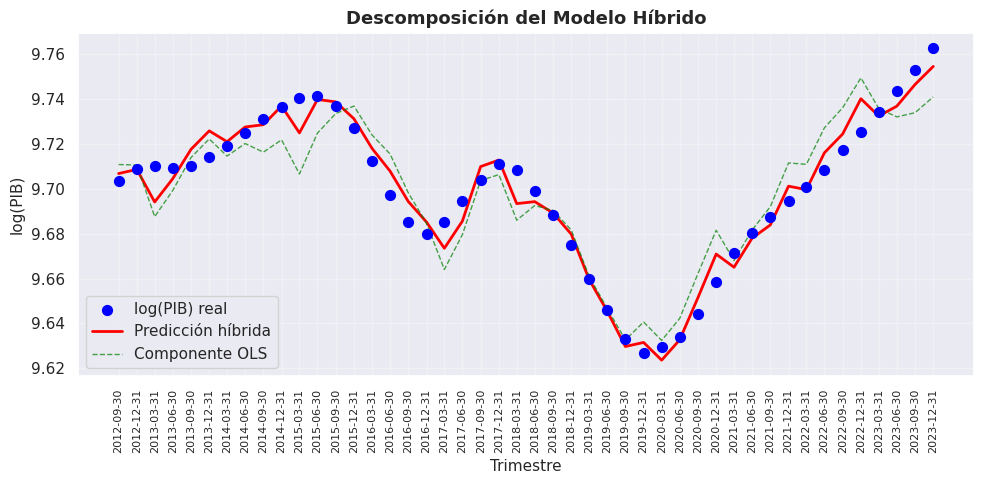

In [ ]:
# OLS + RF on residuals

features = ['total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean', 'year']

X_hybrid = df_ols[features]
y = df_ols['pib_mun']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_hybrid)
X_scaled = pd.DataFrame(X_scaled, columns=X_hybrid.columns, index=X_hybrid.index)

# entrenar ols
X_ols = sm.add_constant(X_scaled)
ols_model = sm.OLS(y, X_ols).fit()
y_hat_ols = ols_model.predict(X_ols)
residuals_ols = y - y_hat_ols

# entrenar RF
rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=10, random_state=42)
rf.fit(X_scaled, residuals_ols)
# pred hyb
y_pred_ols = y_hat_ols
y_pred_rf = rf.predict(X_scaled)
y_pred_hybrid = y_pred_ols + y_pred_rf

#
mse = mean_squared_error(y, y_pred_hybrid)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred_hybrid)

y_real = np.exp(y)
y_pred_real = np.exp(y_pred_hybrid)
mape = np.mean(np.abs((y_real - y_pred_real) / y_real)) * 100


hybrid_metrics = [{
    'MSE': mse,
    'RMSE': rmse,
    'MAE': mae,
    'MAPE': mape
}]



df_hybrid_viz = X_hybrid.copy()
df_hybrid_viz['fecha'] = df_ols['fecha']
df_hybrid_viz['y_real'] = y
df_hybrid_viz['y_pred'] = y_pred_hybrid
df_hybrid_viz['y_pred_ols'] = y_pred_ols
df_hybrid_viz['y_pred_rf'] = y_pred_rf


plot_model(df_hybrid_viz, hybrid_metrics, model='Híbrido (OLS + RF en resids)')

# componentes
plt.figure(figsize=(10, 5))
plt.title('Descomposición del Modelo Híbrido', fontsize=13, fontweight="bold")
plt.scatter(df_hybrid_viz['fecha'], df_hybrid_viz['y_real'],
           label='log(PIB) real', color='blue', s=50, zorder=3)
plt.plot(df_hybrid_viz['fecha'], df_hybrid_viz['y_pred'],
        label='Predicción híbrida', color='red', linewidth=2)
plt.plot(df_hybrid_viz['fecha'], df_hybrid_viz['y_pred_ols'],
        label='Componente OLS', color='green', linewidth=1, linestyle='--', alpha=0.7)

plt.xticks(ticks=df_hybrid_viz['fecha'],
          labels=df_hybrid_viz['fecha'].dt.strftime('%Y-%m-%d'),
          rotation=90, fontsize=8)
plt.ylabel('log(PIB)', fontsize=11)
plt.xlabel('Trimestre', fontsize=11)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

def get_elasticity(x, y_pred, mun, plot=False):
    x = np.array(x)
    y_pred = np.array(y_pred)

    pct_change_x = (x[1:] - x[:-1]) / x[:-1]
    pct_change_y = (y_pred[1:] - y_pred[:-1]) / y_pred[:-1]

    mask = np.abs(pct_change_x) > 1e-3  # ignorar cercanos a cero
    elasticity = pct_change_y[mask] / pct_change_x[mask]


    elasticity_avg = np.mean(elasticity)

    if plot:
      plt.figure(figsize=(8, 4))
      plt.plot(elasticity, marker='o', alpha=0.7)
      plt.axhline(elasticity_avg, color='red', linestyle='--', label=f'Promedio = {elasticity_avg:.2f}')
      plt.title(f"Elasticidad Predicción-Variable en el tiempo: {mun.capitalize()}")
      plt.xlabel("t")
      plt.ylabel("Elasticidad")
      plt.legend()
      plt.show()

    return elasticity_avg, elasticity


def prueba_adf(series, name="Series"):
    result = adfuller(series.dropna())
    print(f"\n Prueba ADF {name}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4e}")
    print(f"Valores críticos:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    if result[1] < 0.05:
        print("Serie estacionaria")
    else:
        print("Serie no es estacionaria")


In [ ]:
# Prueba ADF y elasticidad por  mun
elasticity_results_mun = {}

municipios = ['oaxaca de juarez']

feat_plot = ['suma_rad_trend_sum']


df_hybrid_viz = X_hybrid.copy()
df_hybrid_viz['fecha'] = df_ols['fecha']
df_hybrid_viz['y_real'] = y
df_hybrid_viz['y_pred'] = y_pred_hybrid
df_hybrid_viz['y_pred_ols'] = y_pred_ols
df_hybrid_viz['y_pred_rf'] = y_pred_rf

m = 'oaxaca de juarez'

for feature in feat_plot:
  print(f"=== Feature: {feature}")
  x_m = df_hybrid_viz[feature]
  x_m = 0.4348399868*x_m
  y_pred_m = df_hybrid_viz['y_pred']
  elasticity_avg, serie_E = get_elasticity(x_m, y_pred_m, m)
  prueba_adf(pd.Series(serie_E), f"Elasticidad {m.capitalize()}")
  print(f"Elasticidad {m.capitalize()}: {elasticity_avg}")
  elasticity_results_mun[m] = elasticity_avg


=== Feature: suma_rad_trend_sum

 Prueba ADF Elasticidad Oaxaca de juarez
ADF Statistic: -4.1186
p-value: 9.0215e-04
Valores críticos:
   1%: -3.7377
   5%: -2.9922
   10%: -2.6357
Serie estacionaria
Elasticidad Oaxaca de juarez: 0.1667238401984864
